Velocidades radiales
==

Autores
---
J.P. Calderón & R. Gamen

Resumen
---
En esta práctica vamos a medir una serie de líneas espectrales de la estrella gigante tipo OIII, HD 156292. 
Vamos a reconocer las líneas presentes y medirlas mediante las facilidades de python. Luego, analizaremos
el comportamiento de las velocidades radiales determinadas a partir del efecto Doppler.

Referencias
---
* [Práctica 07 (overleaf)](https://www.overleaf.com/read/ngvwpfpjtfhh)

---

Ejercicios
---
Objetivos:
*  Estudiar la posible periodicidad de la longitud de onda central de estas líneas con el tiempo, 
o equivalentemente, de la velocidad radial que representa este desplazamiento.

In [1]:
import glob
list = sorted ( glob.glob('*.fits') )

In [2]:
list

['tp07_001.fits',
 'tp07_002.fits',
 'tp07_003.fits',
 'tp07_004.fits',
 'tp07_005.fits',
 'tp07_006.fits',
 'tp07_007.fits',
 'tp07_008.fits',
 'tp07_009.fits',
 'tp07_010.fits']

In [3]:
from specutils import Spectrum1D

spec = [ 'None' ] * len(list) # Se crea una _lista_ vacia de 10 elementos.
for i, filename in enumerate(list):
    print (i, filename)
    spec[i] = Spectrum1D.read ( filename )

0 tp07_001.fits


1 tp07_002.fits
2 tp07_003.fits
3 tp07_004.fits
4 tp07_005.fits
5 tp07_006.fits
6 tp07_007.fits
7 tp07_008.fits
8 tp07_009.fits
9 tp07_010.fits


In [4]:
type(spec[0])

specutils.spectra.spectrum1d.Spectrum1D

In [5]:
from astropy.io import fits
with fits.open(list[0]) as hdul:
    hdul.info()
    
hdr = hdul[0].header
hdr

Filename: tp07_001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     107   (224,)   float32   


SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    1 / Number of axes                                 
NAXIS1  =                  224 / Axis length                                    
EXTEND  =                    F / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2020-05-18T12:32:03' / Date FITS file was generated                  
IRAF-TLM= '2020-05-18T20:14:36' / Time of last modification                     
OBJECT  = 'HD156292'           / Name of the object observed                    
OBSERVAT= 'CASLEO             '  / observatory                                  
DATE-OBS= '2008-06-25T00:00:00.0' / date (yyyy-mm-dd) of obs.                   
UT      = ''07:08:37''         / universal time                                 
ST      =           '20:44:5

## 1. Visualizar los espectros

Para analizar el conjunto de datos resulta útil ver todos los espectros juntos. En particular, los espectros utilizados en esta práctica están "normalizados" y calibrados en longitud de onda, pero sin corregir por los movimientos "relativos".

Explique a cuáles movimientos nos referimos. La velocidad radial que se puede determinar a partir de estos espectros: ¿qué representa?

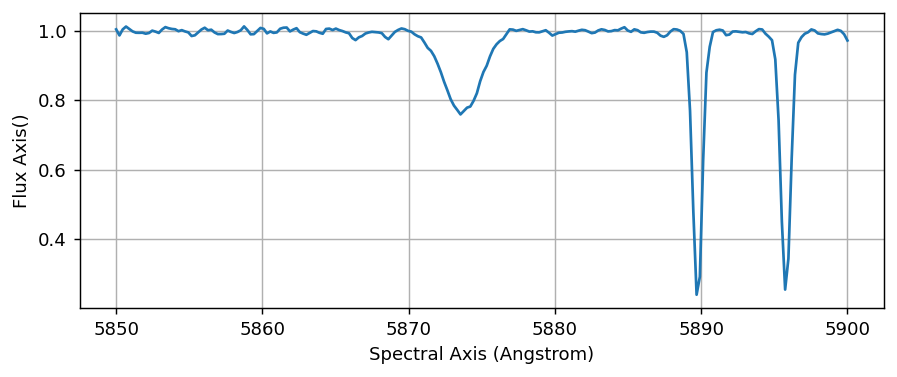

In [6]:
%matplotlib inline
from matplotlib import pyplot as plt
import lineid_plot

spectrum = spec[0] # Indicar el espectro según el índice en la _lista_ spec.

fig, ax = plt.subplots( figsize = (7, 3), dpi = 130 )
ax.plot ( spectrum.spectral_axis, spectrum.flux ) 
ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

ax.grid ( True ) 
fig.tight_layout()
plt.show()

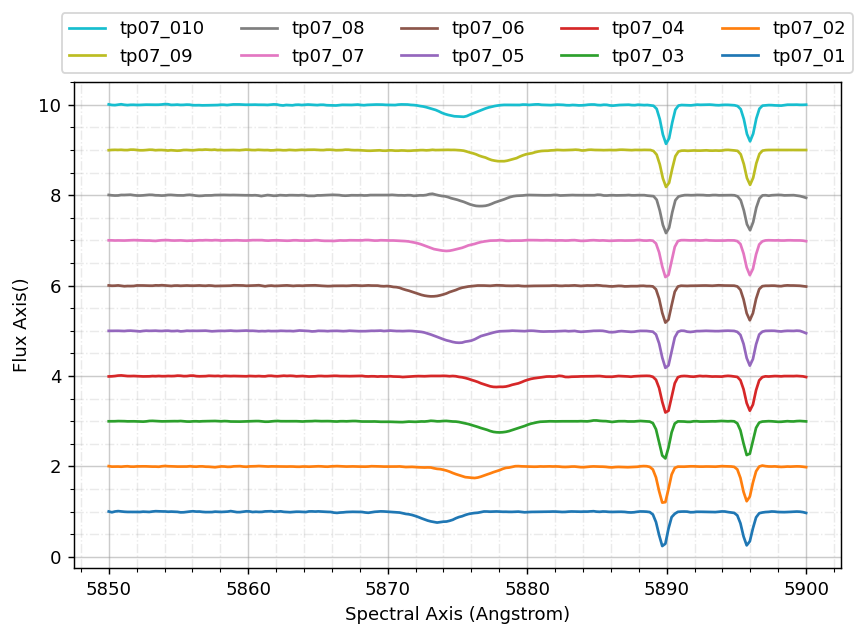

In [7]:
%matplotlib inline
from matplotlib import pyplot as plt

fig, ax = plt.subplots( figsize = (7, 5), dpi = 130 )

for i in range(0, 10):
    ax.plot ( spec[i].spectral_axis, spec[i].flux + i * spectrum.flux.unit, label = "tp07_0%0i" % (i+1) ) 

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

plt.minorticks_on()
plt.grid ( b = True, which = 'major', color = '#999999', linestyle ='-', alpha = 0.5 )
plt.grid ( b = True, which = 'minor', color = '#999999', linestyle = '-.', alpha = 0.2 )

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc = "lower center", bbox_to_anchor = (0.5, 1.0), ncol = 5 )
fig.tight_layout()
plt.show()

## 2. Medir la longitud de onda central de cada línea

Mida las velocidades radiales de las tres líneas identificadas en el espectro, sabiendo que pertenecen a:
 
* He I 5875.62 Å
* Na I 5889.95 Å
* Na I 5895.92 Å

In [8]:
HeI_cen = 5875.62
NaIa_cen = 5889.95
NaIb_cen = 5895.92

### 2.1 Ajuste de la línea

El ajuste se debe realizar en dos pasos. Primero se "inicializa" la función que ajuste y despues se le pasan los valores (x,y), para que calcule los parámetros mediante mínimos cuadrados.

En nuestro caso, la función que vamos a usar para ajustar la línea será la suma de un valor base (```bg```, que corresponde al continuo) y una función gaussina ```gs```, que tendra en cuenta el centro de la línea que queremos ajustar.

Inicializador del modelo a ajustar: ```fitter = fitting.LevMarLSQFitter()```

Ajuste del modelo a los datos: ```fit_model = fitter ( init_model, spectrum.spectral_axis, spectrum.flux )```

Nota: el valor ajustado de la longitud de onda central quedará en la variable ```fit_model.mean_1.value```.

\begin{equation}\Large
\textrm{Gaussian1D}(x) = A e^{- \frac{\left(x - x_{0}\right)^{2}}{2 \sigma^{2}}}
\end{equation}

In [9]:
from astropy.modeling import models, fitting

spectrum = spec[2]

#region = [ 5865 * spectrum.spectral_axis.unit, 5885 * spectrum.spectral_axis.unit ]
#mask = ( spectrum.spectral_axis >= region[0] ) & ( spectrum.spectral_axis <= region[1] )  

x = spectrum.spectral_axis #[ mask ] 
y = spectrum.flux #[ mask ]

bg = models.Const1D ( amplitude = 1 * spectrum.flux.unit )
bg.amplitude.fixed = True # Fija el parámetro.
gs = models.Gaussian1D ( amplitude = 0.2 * spectrum.flux.unit, 
                        mean = 5889 * spectrum.spectral_axis.unit, stddev = 1 * spectrum.spectral_axis.unit )

init_model = bg - gs
fitter = fitting.LevMarLSQFitter()
fit_model = fitter ( init_model, spectrum.spectral_axis, spectrum.flux )  

y_fit = fit_model ( x )  

print ( fit_model )  

Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: [0] - [1]
Components: 
    [0]: <Const1D(amplitude=1. )>

    [1]: <Gaussian1D(amplitude=0.84799832 , mean=5889.82466553 Angstrom, stddev=0.33511403 Angstrom)>
Parameters:
    amplitude_0    amplitude_1          mean_1           stddev_1     
                                       Angstrom          Angstrom     
    ----------- ------------------ ---------------- ------------------
            1.0 0.8479983212379503 5889.82466553298 0.3351140250083255


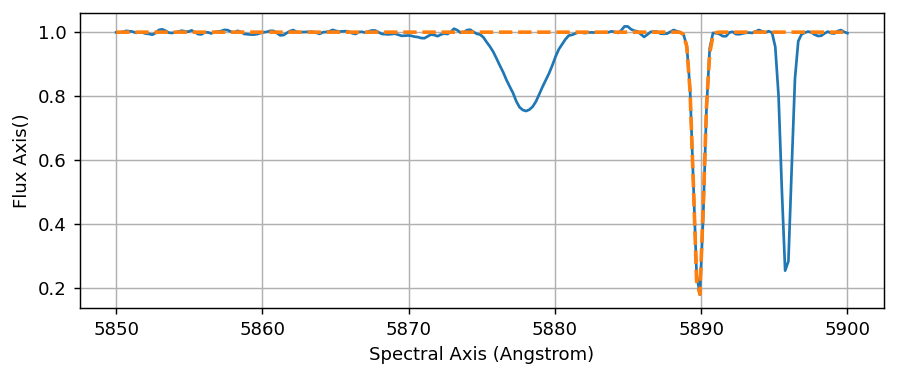

In [10]:
%matplotlib inline
from matplotlib import pyplot as plt

fig, ax = plt.subplots( figsize = (7,3), dpi = 130 )

ax.plot ( spectrum.spectral_axis, spectrum.flux) 
ax.plot ( x, y_fit, linewidth = 2.0, linestyle = 'dashed' )

ax.set_xlabel ( 'Spectral Axis ({})'.format ( spectrum.spectral_axis.unit) ) 
ax.set_ylabel ( 'Flux Axis({})'.format ( spectrum.flux.unit) ) 

ax.grid ( True ) 
fig.tight_layout()
plt.show()

### 2.2 Ajuste de todos los espectros en secuencia

In [16]:
HeI = [ 'None' ] * len ( spec )
for i in range(0, 10):
    spectrum = spec[i]
    x = spectrum.spectral_axis 
    y = spectrum.flux 

    # COMPLETAR

In [17]:
HeI

[5873.652854350275,
 5876.020084407816,
 5878.019876154173,
 5878.03238768369,
 5875.088241534231,
 5873.114602531719,
 5874.203839945513,
 5876.613939638369,
 5878.153532448053,
 5875.071417970242]

In [23]:
NaIa = [ 'None' ] * len ( spec )
for i in range(0, 10):
    spectrum = spec[i]
    x = spectrum.spectral_axis 
    y = spectrum.flux 

    # COMPLETAR

In [24]:
NaIa

[5889.752074326356,
 5889.76969122809,
 5889.8240379747385,
 5889.9811825092365,
 5889.960150435787,
 5889.952121658829,
 5889.966415292681,
 5889.969539920807,
 5889.989298439196,
 5889.973772378349]

In [26]:
NaIb = [ 'None' ] * len ( spec )
for i in range(0, 10):
    spectrum = spec[i]
    x = spectrum.spectral_axis 
    y = spectrum.flux 

    # COMPLETAR

In [27]:
NaIb

[5895.78741421762,
 5895.766464366414,
 5895.824182067652,
 5895.974565555168,
 5895.965632886213,
 5895.955829155468,
 5895.97151607173,
 5895.952252119082,
 5895.97512536242,
 5895.979788076658]

In [28]:
import pandas as pd

results_tmp = [ 'None' ] * len(list)
for i in range(0, 10):
    with fits.open(list[i]) as hdul:
        hdr = hdul[0].header
        print ( list[i], hdul[0].header['HJD'], hdul[0].header['VHELIO'], HeI[i], NaIa[i], NaIb[i] )
        
    results_tmp[i] = [ list[i], hdul[0].header['HJD'], hdul[0].header['VHELIO'], HeI[i], NaIa[i], NaIb[i] ]
    
results = pd.DataFrame (results_tmp, columns = [ 'filename', 'HJD', 'VHELIO', 'HeI', 'NaIa', 'NaIb'])   

tp07_001.fits 2454642.80305208 -5.8765115367043 5873.652854350275 5889.752074326356 5895.78741421762
tp07_002.fits 2454643.74906005 -6.29750484755869 5876.020084407816 5889.76969122809 5895.766464366414
tp07_003.fits 2454644.77017552 -6.73461126026229 5878.019876154173 5889.8240379747385 5895.824182067652
tp07_004.fits 2454659.74457888 -13.286739614139 5878.03238768369 5889.9811825092365 5895.974565555168
tp07_005.fits 2454660.68801023 -13.5833556767914 5875.088241534231 5889.960150435787 5895.965632886213
tp07_006.fits 2454661.69888929 -14.0236186902435 5873.114602531719 5889.952121658829 5895.955829155468
tp07_007.fits 2454662.72270685 -14.472398558423 5874.203839945513 5889.966415292681 5895.97151607173
tp07_008.fits 2454663.61114853 -14.6288624096429 5876.613939638369 5889.969539920807 5895.952252119082
tp07_009.fits 2454664.62480214 -15.0498561354478 5878.153532448053 5889.989298439196 5895.97512536242
tp07_010.fits 2454665.63529452 -15.4750194293795 5875.071417970242 5889.9737723

In [ ]:
c = 300000

results [ 'VR_HeI'] = ( results['HeI']- HeI_cen ) / HeI_cen * c + results [ 'VHELIO' ]
results [ 'VR_NaIa'] = ( results['NaIa']- NaIa_cen ) / NaIa_cen * c + results [ 'VHELIO' ]
results [ 'VR_NaIb'] = ( results['NaIb']- NaIb_cen ) / NaIb_cen * c + results [ 'VHELIO' ]
results [ 'HJD0'] = results [ 'HJD'] - 2454000.0

fig, ax = plt.subplots( figsize = (7,5), dpi = 130 )

ax.scatter ( 'HJD0', 'VR_HeI', data = results, 
            alpha = 1.0, s = 5**2, edgecolor = 'white', zorder = 10, label = "HeI" ) 
ax.scatter ( 'HJD0', 'VR_NaIa', data = results,
            alpha = 1.0, s = 5**2, edgecolor = 'white', zorder = 10, label = "NaI" ) 
ax.scatter ( 'HJD0', 'VR_NaIb', data = results, 
            alpha = 1.0, s = 5**2, edgecolor = 'white', zorder = 10, label = "NaI" ) 
ax.axhline ( y = 0, color = 'black', linestyle = 'dashed', linewidth = 1, alpha = 0.5, zorder = -1 )

ax.set_xlabel ( 'HJD-2454000 [d]' )
ax.set_ylabel ( 'VR [km s$^{-1}$]') 

# Show the minor grid lines with very faint and almost transparent grey lines
plt.minorticks_on()
plt.grid ( b = True, which = 'major', color = '#999999', linestyle ='-', alpha = 0.5 )
plt.grid ( b = True, which = 'minor', color = '#999999', linestyle = '-.', alpha = 0.2 )

handles, labels = ax.get_legend_handles_labels()
ax.legend( loc = "lower center", bbox_to_anchor = (0.5, 1.0), ncol = 3 )
fig.tight_layout()
plt.show()

## 3. Calcule el período de las variaciones en velocidad radial
Utilizaremos el método Lomb-Scargle para calcular el periodograma y derivar el período de movimiento.

Referencias:
* https://docs.astropy.org/en/stable/timeseries/lombscargle.html
* https://ui.adsabs.harvard.edu/abs/2018ApJS..236...16V/abstract

In [30]:
from astropy.timeseries import LombScargle
import numpy as np
frequency, power = LombScargle ( results['HJD'], results['VR_HeI'] ).autopower ( minimum_frequency = 0.1,
                                                                                maximum_frequency = 10,
                                                                                samples_per_peak = 10 )
period = 1./frequency
best_period = period[np.argmax(power)]
print ( "Mejor período: %.3f (días)" % (best_period) )

Mejor período: 4.875 (días)


### 3.1 Calculo la fase del movimiento

/home/juanpablo/.conda/envs/work/lib/python3.7/site-packages/ipykernel_launcher.py:24: MatplotlibDeprecationWarning: The 's' parameter of annotate() has been renamed 'text' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.


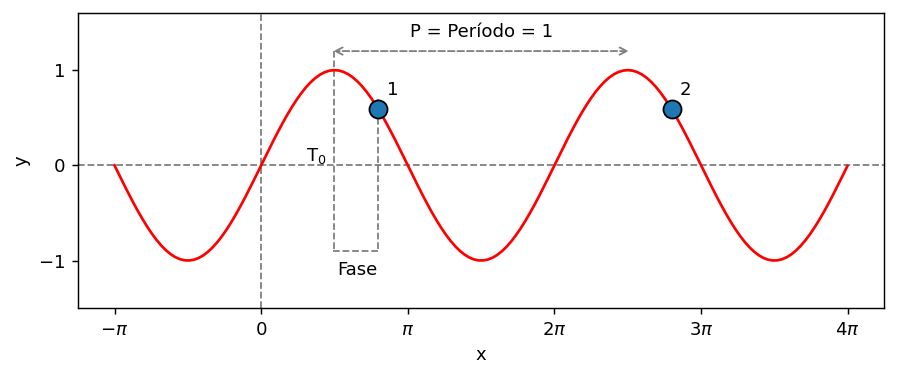

In [31]:
x = np.arange ( -np.pi, 4*np.pi, 0.1)

%matplotlib inline
fig, ax = plt.subplots( figsize = (7,3), dpi = 130 )

ax.scatter ( 0.8*np.pi, np.sin(0.8*np.pi), color = "tab:blue", edgecolor = "black", s = 10**2, zorder = 10 )
ax.scatter ( 2.8*np.pi, np.sin(2.8*np.pi), color = "tab:blue", edgecolor = "black", s = 10**2, zorder = 10 )
ax.text (0.8*np.pi+0.3, np.sin(0.8*np.pi)+0.2, '1', horizontalalignment = 'center', verticalalignment = 'center' ) 
ax.text (2.8*np.pi+0.3, np.sin(2.8*np.pi)+0.2, '2', horizontalalignment = 'center', verticalalignment = 'center' ) 

ax.plot ( x, np.sin(x), color = "red", zorder = 9 )
ax.axhline ( y = 0, color = 'black', linestyle = 'dashed', linewidth = 1, alpha = 0.5, zorder = -1 )
ax.axvline ( x = 0, color = 'black', linestyle = 'dashed', linewidth = 1, alpha = 0.5, zorder = -1 )

ax.axvline ( np.pi/2, 0.2, 0.87, color = 'black', linestyle = 'dashed', linewidth = 1, alpha = 0.5, zorder = -1 )
ax.axvline ( 0.8*np.pi, 0.2, 0.71, color = 'black', linestyle = 'dashed', linewidth = 1, alpha = 0.5, zorder = -1 )
ax.axhline ( -0.9, 0.316, 0.375, color = 'black', linestyle = 'dashed', linewidth = 1, alpha = 0.5, zorder = -1 )
ax.text ( np.pi/2+0.5, -1.1, 'Fase', horizontalalignment = 'center', verticalalignment = 'center' ) 

ax.text ( np.pi/2-0.4, 0.1, 'T$_{0}$', horizontalalignment = 'center', verticalalignment = 'center' ) 

ax.text ( (3./2.)*np.pi, 1.4, 'P = Período = 1', horizontalalignment = 'center', verticalalignment = 'center' ) 
ax.annotate ( s = '', xy = (np.pi/2-0.1,1.2), xytext = (2.5*np.pi+0.1,1.2), 
             arrowprops = dict ( arrowstyle = '<->', color = 'gray',  linestyle = 'dashed', linewidth = 1 ) )

ax.set_ylim ( -1.5, 1.6 )
ax.set_xlabel ( 'x' )
ax.set_ylabel ( 'y' ) 

plt.xticks ( [-np.pi, 0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi ], 
            [r'$-\pi$', r'$0$', r'$\pi$', r'$2\pi$', r'$3\pi$', r'$4\pi$' ] )
plt.yticks ( [-1, 0, +1], [r'$-1$', r'$0$', r'$1$'] )

fig.tight_layout()
plt.show()

In [32]:
phase = (results['HJD'] / best_period) % 1  

In [ ]:
phase

### 3.2 Curva de luz

In [ ]:
%matplotlib inline
from astropy.modeling.models import Sine1D

r = np.arange ( 0, 1, 0.01 )
init_model = models.Const1D ( amplitude = -10 ) + Sine1D ( amplitude = 130, frequency = 1.0, phase = 1.0 )

fitter = fitting.LevMarLSQFitter()
fit_model = fitter ( init_model, phase, results['VR_HeI'] )  
y_fit = fit_model ( phase ) 

fig, (ax0, ax1) = plt.subplots ( ncols = 2, nrows = 1, figsize = (10, 4), dpi = 130 )

ax0.plot ( period, power, lw = 0.5 )
ax0.axvline( best_period, color = 'red', alpha = 0.2, linewidth = 10, zorder = -10  )
ax0.text ( 0.03, 0.93,'period = {:.3f} days'.format( best_period ), 
         transform = ax0.transAxes, color = 'red' )
   
ax0.set_xlabel ( 'Período [d]' )
ax0.set_ylabel ( 'Probabilidad' )    
    
ax1.scatter ( phase,results['VR_HeI'], zorder = 10 )
ax1.plot ( r, init_model(r), c = 'black', linestyle = 'dashed', zorder = 9 )
ax1.axhline ( y = 0, color = 'black', linestyle = 'dashed', linewidth = 1, alpha = 0.5, zorder = -1 )

ax1.set_xlabel ( 'Fase [d]' )
ax1.set_ylabel ( 'VR [km s$^{-1}$]') 

fig.tight_layout()
plt.show()  

In [ ]:
print ( fit_model )  

In [ ]:
%matplotlib inline
from astropy.modeling.models import Sine1D

fig, ax = plt.subplots( figsize = (7,3), dpi = 130 )
ax.scatter ( phase,results['VR_HeI'], zorder = 10, label = "HeI" )
ax.plot ( r, init_model(r), c = 'black', linestyle = 'dashed', zorder = 9 )
ax.axhline ( y = 0, color = 'black', linestyle = 'dashed', linewidth = 1, alpha = 0.5, zorder = -1 )

ax.set_xlabel ( 'Fase [d]' )
ax.set_ylabel ( 'VR [km s$^{-1}$]') 

plt.legend()
plt.show()